In [3]:
import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
# Helpful statement for debugging, prints the thing entered as x and the output, i.e.,
# debugPrint(1+1) will output '1+1 [int] = 2'
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
    
    
import os, sys
import torch
import numpy as np

# Warp-based Radius Search Implementation
import warp as wp

# Initialize Warp
wp.init()

from sphWarpCore.math import *
from sphWarpCore.util import castTorchToWarp, castWarpToTorch, castTorchToWarpAsBuiltins
from sphWarpCore.radiusSearch.wp_radius_small import warp_radius_search_small
from sphWarpCore.radius import *
from warp.types import vector
from sphWarpCore.autograd import warpWrapper, WarpFunctionWrapper
from sphWarpCore.ops import *
import matplotlib.pyplot as plt

wp.config.verify_autograd_array_access = True
wp.config.verbose = True


Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [4]:
@torch.jit.script
def volumeToSupport(volume : float, targetNeighbors : int, dim : int):
    """
    Calculates the support radius based on the given volume, target number of neighbors, and dimension.

    Parameters:
    volume (float): The volume of the support region.
    targetNeighbors (int): The desired number of neighbors.
    dim (int): The dimension of the space.

    Returns:
    torch.Tensor: The support radius.
    """
    if dim == 1:
        # N_h = 2 h / v -> h = N_h * v / 2
        return targetNeighbors * volume / 2
    elif dim == 2:
        # N_h = \pi h^2 / v -> h = \sqrt{N_h * v / \pi}
        return torch.sqrt(targetNeighbors * volume / np.pi)
    else:
        # N_h = 4/3 \pi h^3 / v -> h = \sqrt[3]{N_h * v / \pi * 3/4}
        return torch.pow(targetNeighbors * volume / np.pi * 3 /4, 1/3)
    
def generateNeighborTestData(nx, targetNumNeighbors, dim, periodic, device):


    minDomain = torch.tensor([-1] * dim, dtype = torch.float32, device = device)
    maxDomain = torch.tensor([ 1] * dim, dtype = torch.float32, device = device)
    periodicity = torch.tensor([periodic] * dim, device = device, dtype = torch.bool)

    extent = maxDomain - minDomain
    shortExtent = torch.min(extent, dim = 0)[0].item()
    dx = (shortExtent / nx)
    ny = int(1 // dx)
    h = volumeToSupport(dx**dim, targetNumNeighbors, dim)
    dy = dx / 1.5
    ny = int(1 // dy)

    positions = []
    for d in range(dim):
        positions.append(torch.linspace(minDomain[d] + dx / 2, maxDomain[d] - dx / 2, int((extent[d] - dx) / dx) + 1, device = device))
    grid = torch.meshgrid(*positions, indexing = 'xy')
    
    positions = torch.stack(grid, dim = -1).reshape(-1,dim).to(device)
    supports = torch.ones(positions.shape[0], device = device) * h
    
    domain = DomainDescription(minDomain, maxDomain, periodicity, dim)
    
    return positions, supports, positions.shape[0], domain, dx

In [5]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# if platform.system() == 'Darwin':
    # device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 32
dim = 2
numParticles = nx**dim

def getNextPrime(n):
    # Compute the next larger prime number greater than n
    # used primarily to set the hash map length to a prime number for better distribution of particles in the hash map
    
    def is_prime(num):
        if num <= 1:
            return False
        for i in range(2, int(num**0.5) + 1):
            if num % i == 0:
                return False
        return True
    
    prime = n + 1
    while True:
        if is_prime(prime):
            return prime
        prime += 1

# hashMapLength = getNextPrime(numParticles)
# periodic = False
# x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

# pointCloud = PointCloud(x, h)
# queryPositions = pointCloud.positions
# querySupports = pointCloud.supports
# referencePositions = pointCloud.positions
# referenceSupports = pointCloud.supports
# mode = 'gather'

# offset = 0

In [6]:

device = torch.device(device)
numParticles = nx**dim
hashMapLength = getNextPrime(numParticles)
periodic = False
x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, True, device)

x += torch.randn_like(x) * dx * 0.1

pointCloud = PointCloud(x, h)
queryPositions = pointCloud.positions.contiguous()
querySupports = pointCloud.supports
referencePositions = pointCloud.positions.contiguous()
referenceSupports = pointCloud.supports

queryMasses = torch.ones(x.shape[0], device = x.device) * dx**dim
referenceMasses = torch.ones(x.shape[0], device = x.device) * dx**dim

mode = 'gather'

In [7]:
adjacency = radiusSearchCompactHashMap(
        queryPositions, referencePositions, 
        querySupports, referenceSupports, 
        domain.periodic, domain,
        mode, hashMapLength
)

Module sphWarpCore.radiusSearch.wp_compactHash e2c9126 load on device 'cuda:0' (block_dim=256) ...
            hashValue += wp.uint32(cellIndex[d] * primes[d])

            continue  # No particles in this cell

        dist_sq += dx * dx

                    count += 1

                    count += 1

            continue  # No particles in this cell

                    edge_index += 1

                    edge_index += 1

    Compile CUDA (arch=120, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/lu26029/.cache/warp/1.12.0/wp_sphWarpCore.radiusSearch.wp_compactHash_e2c9126.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incompati

In [8]:

import diffSPH
from diffSPH.sampling import ParticleSet
from diffSPH.schemes.states.common import BasicState
from diffSPH.modules.density import computeDensity
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr
from diffSPH.kernels import *
from diffSPH.neighborhood import evaluateNeighborhood, SupportScheme, computeNeighborhoodStates
from diffSPH.enums import Operation, SupportScheme, GradientMode, LaplacianMode
from diffSPH.operations import SPHOperation

particles_l = ParticleSet(positions = referencePositions, supports = referenceSupports, masses = referenceMasses, densities = torch.zeros_like(referenceMasses))

positions_t = referencePositions.clone()
simulationState = BasicState(
    positions = positions_t,
    supports = particles_l.supports,
    masses = particles_l.masses,
    densities = particles_l.densities,        
    velocities = torch.zeros_like(referencePositions),
    kinds = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
    materials = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
    UIDs = torch.arange(referencePositions.shape[0], device = referencePositions.device)
)

# neighborhood, neighbors = evaluateNeighborhood(simulationState, domain,  KernelType.Wendland4, verletScale =1.0, mode = SupportScheme.Gather, priorNeighborhood=None, computeHessian=False, computeDkDh=False, only_j = False)
neighborhood, sparseNeighborhood_ = buildNeighborhood(simulationState, simulationState, domain, verletScale = 1.0, mode = 'gather', priorNeighborhood=None)

state = computeNeighborhoodStates(simulationState, sparseNeighborhood_, 'gather', KernelType.Wendland2, KernelType.Wendland2, True, True, False)

neighborhood = state.get('noghost')


In [9]:
from sphWarpCore.ops import sphOperation_warp

In [10]:
from sphWarpCore.enumTypes import *

[Kernel.add_overload] Creating new overload for computeSPHDensity_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1b_u4_i4_a1i8_a1i4_a1i4_i4_a1i4_a1i4_a1f4
Module sphWarpCore.operations.wp_density 536e81d load on device 'cuda:0' (block_dim=256) ...
        f_interpolated += masses[j] * sphKernel(xi, positions[j], hi, supports[j], kernel_int, mode_uint, periodicity, domainMin, domainMax) 

    Compile CUDA (arch=120, mode=release, block_dim=256) ...
"wp_sphWarpCore.operations.wp_density_536e81d.cu": using precompiled header file "/home/lu26029/.cache/warp/1.12.0/wp_sphWarpCore.radiusSearch.wp_compactHash_e2c9126.pch"
    Compile CUDA (arch=120, mode=release, block_dim=256) took 124.27 ms
Module sphWarpCore.operations.wp_density 536e81d load on device 'cuda:0' (block_dim=256) took 162.40 ms  (compiled)


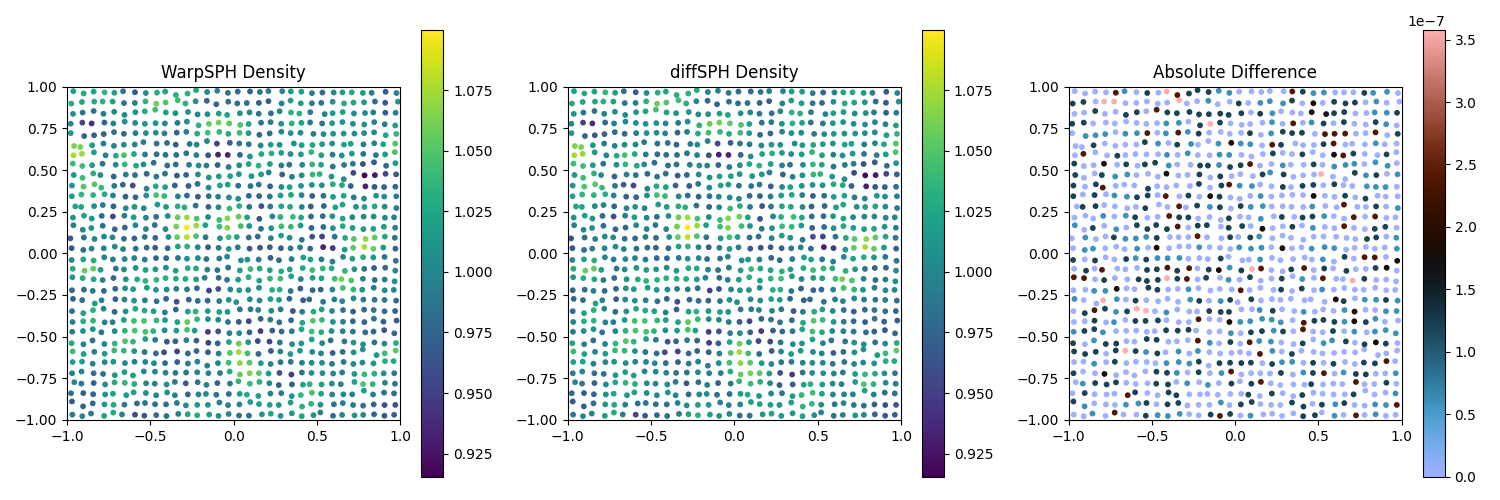

In [11]:
densities_warp = sphOperation_warp(
        queryPositions, referencePositions, 
        querySupports, referenceSupports, 
        queryMasses, referenceMasses,
        None, None, 
        None, None, 
        domain, adjacency,
        operation=WarpOperation.Density,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather
)
queryDensities = densities_warp
referenceDensities = densities_warp

densities_diffSPH = SPHOperation(
        simulationState,
        quantity = None,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Density,
        supportScheme = SupportScheme.Gather,
        correctionTerms= [],
        positiveDivergence=False
        )
simulationState.densities = densities_diffSPH


fig, axis = plt.subplots(1,3, figsize = (15,5), squeeze=False)

c = axis[0,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = densities_warp.cpu(), s = 10)
axis[0,0].set_title("WarpSPH Density")
fig.colorbar(c, ax = axis[0,0])

c = axis[0,1].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = densities_diffSPH.cpu(), s = 10)
axis[0,1].set_title("diffSPH Density")
fig.colorbar(c, ax = axis[0,1])

diff = torch.abs(densities_warp - densities_diffSPH)
c = axis[0,2].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = diff.cpu(), s = 10, cmap = 'berlin')
axis[0,2].set_title("Absolute Difference")
fig.colorbar(c, ax = axis[0,2])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()


In [12]:

from diffSPH.modules.CRKSPH import computeCRKVolume, computeGeometricMoments, computeCRKTerms, computeCRKDensity, computeVelocityTensor, computeCRKdvdt, computeCRKdudt

from diffSPH.enums import SupportScheme as DiffSPHSupportScheme, KernelType as DiffSPHKernelType, KernelCorrectionScheme


In [13]:

simulationState.omega = torch.ones_like(simulationState.masses)
simulationState.apparentArea = computeCRKVolume(simulationState, KernelType.Wendland2, neighborhood, DiffSPHSupportScheme.Gather, {})
kernelMoments = computeGeometricMoments(simulationState, KernelType.Wendland2, neighborhood, DiffSPHSupportScheme.SuperSymmetric, {})       
simulationState.numNeighbors = adjacency.numNeighbors
simulationState.A, simulationState.B, simulationState.gradA, simulationState.gradB = computeCRKTerms(kernelMoments, simulationState.numNeighbors, simulationState.supports)
# simulationState.A, simulationState.B = None, None
simulationState.densities = computeCRKDensity(simulationState, KernelType.Wendland2, neighborhood, SupportScheme.SuperSymmetric, {})
f = 2 + queryPositions[:,0] * 20

In [103]:
from diffSPH.sphOperations.shared import get_i, get_j, mod_distance, getSupport, scatter_sum, product
from diffSPH.neighborhood import evalKernel, evalKernelGradient, evalKernelDkDh

i = neighborhood[0].row
j = neighborhood[0].col

x_ij = neighborhood[1].x_ij    
V_j = simulationState.apparentArea[j]

W_ij = evalKernel(neighborhood[1], supportScheme=DiffSPHSupportScheme.SuperSymmetric, combined=True)
gradW_ij = evalKernelGradient(neighborhood[1], supportScheme=DiffSPHSupportScheme.SuperSymmetric, combined=True)

dyadicProduct = lambda a, b: torch.einsum('i...j,i...k->i...jk', a, b)
delta = lambda i, j: 1 if i == j else 0
nu = x_ij.shape[1]
dtype = x_ij.dtype
device = x_ij.device
eye = torch.eye(nu, dtype = dtype, device = device)

m_0 = V_j * W_ij
m_1 = x_ij * (V_j * W_ij).view(-1, 1)
m_2 = dyadicProduct(x_ij, x_ij) * (V_j * W_ij).view(-1, 1, 1)
m_0 = scatter_sum(m_0, i, dim = 0, dim_size = simulationState.positions.shape[0])
m_1 = scatter_sum(m_1, i, dim = 0, dim_size = simulationState.positions.shape[0])
m_2 = scatter_sum(m_2, i, dim = 0, dim_size = simulationState.positions.shape[0])

In [104]:
m_2_inv = torch.linalg.pinv(m_2)
A = 1 / (m_0 - torch.einsum('nij, ni, nj -> n', m_2_inv, m_1, m_1))
B = - torch.einsum('nij, nj -> ni', m_2_inv, m_1)

In [105]:
num_nbrs = simulationState.numNeighbors

m_2_det = torch.det(m_2).abs()
is_singular = torch.where(m_2_det < 1e-10, 1.0, 0.0)
mask = (num_nbrs < 2) | (is_singular > 0.0)

A[mask] = 1.0
for i in range(nu):
    # gradA[mask, i] = 0.0
    B[mask, i] = 0.0
    # for j in range(nu):
        # gradB[mask, i, j] = 0.0

In [106]:


def correctedKernel(A, B, kernelValues, supportScheme: SupportScheme = SupportScheme.SuperSymmetric, xji: bool = False):
    fac = -1 if xji else 1
    prod = torch.einsum('...i, ...i -> ...', B, fac * kernelValues.x_ij)
    W_ij = evalKernel(kernelValues, supportScheme=supportScheme, combined=True)
    return A * (1 + prod) * W_ij

In [107]:
j = neighborhood[0].col
i = neighborhood[0].row

fj = f[j]
Vj = simulationState.apparentArea[j]

W_ij = correctedKernel(A[i], B[i], neighborhood[1], supportScheme=DiffSPHSupportScheme.SuperSymmetric)

Term = Vj * W_ij * fj
result = scatter_sum(Term, i, dim = 0, dim_size = simulationState.positions.shape[0])

In [108]:
# simulationState.A = A
# simulationState.B = B
f_interp_CRK = SPHOperation(
        simulationState,
        quantity = f,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation= Operation.Interpolate,
        supportScheme = DiffSPHSupportScheme.SuperSymmetric,
        correctionTerms= [KernelCorrectionScheme.CRKSPH],
        positiveDivergence=False,
        useApparentArea=True
        )

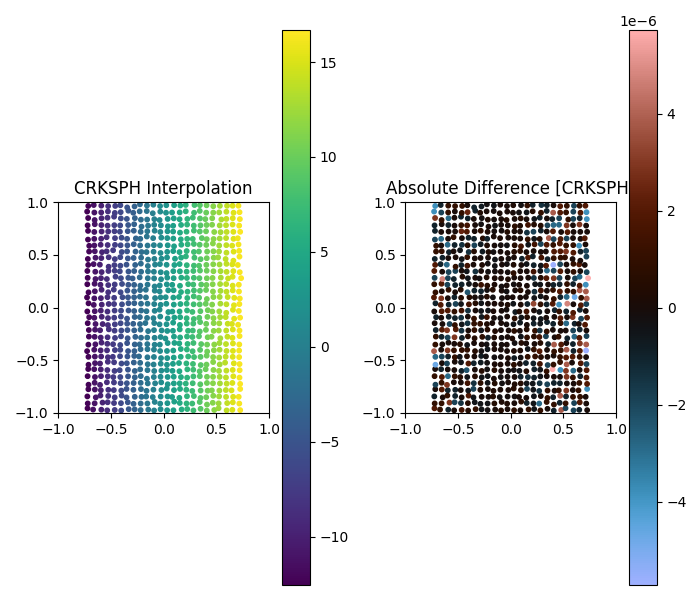

In [109]:
mask = torch.logical_and(referencePositions[:,0] > -0.75, referencePositions[:,0] < 0.75)

fig, axis = plt.subplots(1, 2, figsize = (7,6), squeeze=False)

c = axis[0,0].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = result[mask].cpu(), s = 10)
axis[0,0].set_title("CRKSPH Interpolation")
fig.colorbar(c, ax = axis[0,0])

diff = (result - f)
c = axis[0,1].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = diff[mask].cpu(), s = 10, cmap = 'berlin')
axis[0,1].set_title("Absolute Difference [CRKSPH]")
fig.colorbar(c, ax = axis[0,1])

for a in axis.flatten():
    a.set_aspect('equal')
    a.set_xlim(domain.min[0].item(), domain.max[0].item())
    a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [110]:

# simulationState.densities = computeDensity(simulationState, KernelType.Wendland2, neighborhood, DiffSPHSupportScheme.Gather)

# f_interp = SPHOperation(
#         simulationState,
#         quantity = f,
#         kernel = KernelType.Wendland2,
#         neighborhood = neighborhood[0],
#         kernelValues = neighborhood[1],
#         operation= Operation.Interpolate,
#         supportScheme = DiffSPHSupportScheme.SuperSymmetric,
#         correctionTerms= [],
#         positiveDivergence=False
#         )


# fig, axis = plt.subplots(2, 2, figsize = (7,6), squeeze=False)

# c = axis[0,0].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = f_interp_crk[mask].cpu(), s = 10)
# axis[0,0].set_title("CRKSPH Interpolation")
# fig.colorbar(c, ax = axis[0,0])

# c = axis[0,1].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = f_interp[mask].cpu(), s = 10)
# axis[0,1].set_title("Standard SPH Interpolation")
# fig.colorbar(c, ax = axis[0,1])

# diff = (f_interp_crk - f)
# c = axis[1,0].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = diff[mask].cpu(), s = 10, cmap = 'berlin')
# axis[1,0].set_title("Absolute Difference [CRKSPH]")
# fig.colorbar(c, ax = axis[1,0])

# diff = (f_interp - f)
# c = axis[1,1].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = diff[mask].cpu(), s = 10, cmap = 'berlin')
# axis[1,1].set_title("Absolute Difference [Standard SPH]")
# fig.colorbar(c, ax = axis[1,1])

# for a in axis.flatten():
#     a.set_aspect('equal')
#     a.set_xlim(domain.min[0].item(), domain.max[0].item())
#     a.set_ylim(domain.min[1].item(), domain.max[1].item())

# fig.tight_layout()

In [111]:
from math import sqrt

def mat_vec_mult(mat, vec, d, out):
    for i in range(d):
        out[i] = 0.0
        for j in range(d):
            out[i] += mat[d*i + j] * vec[j]
    
def dot(vec1, vec2, d):
    res = 0.0
    for i in range(d):
        res += vec1[i] * vec2[i]
    return res

def loop_all(d_idx, 
             d_x, d_y, d_z, d_h, 
             s_x, s_y, s_z, s_h, 
             s_m, s_rho, 
             
             adjacency, d_ai, d_gradai, d_bi, s_V,
                d_gradbi):
    x = d_x[d_idx]
    y = d_y[d_idx]
    z = d_z[d_idx]
    h = d_h[d_idx]
    # i, j, k, s_idx, d, d2 = declare('int', 6)
    # alp, bet, gam, phi, psi = declare('int', 5)
    xij = np.zeros(3, dtype = np.float32)
    dwij = np.zeros(3, dtype = np.float32)
    d = 2
    d2 = d*d

    m0 = 0.0
    m1 = np.zeros(3, dtype = np.float32)
    m2 = np.zeros(9, dtype = np.float32)
    temp_vec = np.zeros(3, dtype = np.float32)
    temp_aug_m2 = np.zeros(18, dtype = np.float32)
    m2inv = np.zeros(9, dtype = np.float32)
    grad_m0 = np.zeros(3, dtype = np.float32)
    grad_m1 = np.zeros(9, dtype = np.float32)
    grad_m2 = np.zeros(27, dtype = np.float32)
    ai = 0.0
    bi = np.zeros(3, dtype = np.float32)
    grad_ai = np.zeros(3, dtype = np.float32)
    grad_bi = np.zeros(9, dtype = np.float32)

    for i in range(3):
        m1[i] = 0.0
        grad_m0[i] = 0.0
        bi[i] = 0.0
        grad_ai[i] = 0.0
        for j in range(3):
            m2[3*i + j] = 0.0
            grad_m1[3*i + j] = 0.0
            grad_bi[3*i + j] = 0.0
            for k in range(3):
                grad_m2[9*i + 3*j + k] = 0.0

    N_NBRS = adjacency.numNeighbors[d_idx]
    for i in range(N_NBRS):
        s_idx = adjacency.j[adjacency.edgeOffsets[d_idx] + i]
        print(f'd_idx: {d_idx}, s_idx: {s_idx}')
        
        xij[0] = x - s_x[s_idx]
        xij[1] = y - s_y[s_idx]
        # xij[2] = z - s_z[s_idx]

        xij = mod_distance(torch.tensor([x,y]).view(-1, 2), torch.tensor([s_x[s_idx], s_y[s_idx]]).view(-1, 2), torch.tensor([True,True]), domain.min, domain.max).numpy().flatten()

        hij = (h + s_h[s_idx]) * 0.5
        rij = sqrt(xij[0] * xij[0] + xij[1] * xij[1])
        wij = Kernel(KernelType.Wendland2, torch.tensor(xij).view(-1, 2), torch.tensor(hij)).item()
        dwij = Kernel_Gradient(KernelType.Wendland2, torch.tensor(xij).view(-1, 2), torch.tensor(hij)).numpy()[0]
        dwij = np.hstack(( dwij, np.zeros(1, dtype = np.float32) ))
        V = 1.0/s_V[s_idx]

        xij = np.hstack((xij, np.zeros(1, dtype = np.float32)))

        m0 += V * wij
        for alp in range(d):
            m1[alp] += V * wij * xij[alp]
            for bet in range(d):
                m2[d*alp + bet] += V * wij * xij[alp] * xij[bet]
        for gam in range(d):
            grad_m0[gam] += V * dwij[gam]
            for alp in range(d):
                fac = 1.0 if alp == gam else 0.0
                temp = (xij[alp] * dwij[gam] + fac * wij)
                grad_m1[d*gam + alp] += V * temp
                for bet in range(d):
                    fac2 = 1.0 if bet == gam else 0.0
                    temp = xij[alp] * fac2 + xij[bet] * fac
                    temp2 = (xij[alp] * xij[bet] * dwij[gam] + temp * wij)
                    grad_m2[d2*gam + d*alp + bet] += V * temp2

    # identity(m2inv, d)
    # augmented_matrix(m2, m2inv, d, d, d, temp_aug_m2)
    print("m2 before inversion:")
    print(m2.reshape(3,3))
    m2inv = np.linalg.pinv(m2[:d2].reshape(2,2)).flatten()
    m2inv = torch.hstack((torch.tensor(m2inv), torch.zeros(5, dtype = torch.float32)))

    # # If is_singular > 0 then matrix was singular
    # is_singular = gj_solve(temp_aug_m2, d, d, m2inv)

    # if is_singular > 0.0:
    #     # Cannot do much if the matrix is singular.  Perhaps later
    #     # we can tag such particles to see if the user can do something.
    #     pass
    # else:
    if True:
        mat_vec_mult(m2inv, m1, d, temp_vec)

        # Eq. 12.
        ai = 1.0/(m0 - dot(temp_vec, m1, d))
        # Eq. 13.
        mat_vec_mult(m2inv, m1, d, bi)
        for gam in range(d):
            bi[gam] = -bi[gam]

        # Eq. 14. and 15.
        for gam in range(d):
            temp1 = grad_m0[gam]
            for alp in range(d):
                temp2 = 0.0
                for bet in range(d):
                    temp1 -= m2inv[d*alp + bet] * (
                        m1[bet] * grad_m1[d*gam + alp] +
                        m1[alp] * grad_m1[d*gam + bet]
                    )
                    temp2 -= (
                        m2inv[d*alp + bet] * grad_m1[d*gam + bet]
                    )
                    for phi in range(d):
                        for psi in range(d):
                            temp1 += (
                                m2inv[d*alp + phi] * m2inv[d*psi + bet] *
                                grad_m2[d2*gam + d*phi + psi] *
                                m1[bet] * m1[alp]
                            )
                            temp2 += (
                                m2inv[d*alp + phi] * m2inv[d*psi + bet] *
                                grad_m2[d2*gam + d*phi + psi] * m1[bet]
                            )
                grad_bi[d*gam + alp] = temp2
            grad_ai[gam] = -ai*ai*temp1

    # if N_NBRS < 2 or is_singular > 0.0:
    #     d_ai[d_idx] = 1.0
    #     for i in range(d):
    #         d_gradai[d * d_idx + i] = 0.0
    #         d_bi[d * d_idx + i] = 0.0
    #         for j in range(d):
    #             d_gradbi[d2 * d_idx + d * i + j] = 0.0
    # else:

    d_ai = ai
    for i in range(d):
        d_gradai[i] = grad_ai[i]
        d_bi[i] = bi[i]
        for j in range(d):
            d_gradbi[d * i + j] = grad_bi[d*i + j]
    
    return d_ai, d_gradai, d_bi, d_gradbi, m0, m1, m2, m2inv

In [121]:
dim = 3
d_ai = np.zeros(1, dtype = np.float32)
d_gradai = np.zeros((dim), dtype = np.float32)
d_bi = np.zeros((dim), dtype = np.float32)
d_gradbi = np.zeros((dim * dim), dtype = np.float32)

x = referencePositions[:,0].cpu().numpy()
y = referencePositions[:,1].cpu().numpy()
z = np.zeros_like(x)

i = 128

d_ai, d_gradai, d_bi, d_gradbi, m0, m1, m2, m2inv = loop_all(i, 
         
         x, y, z, h.cpu().numpy(), 
         x, y, z, h.cpu().numpy(), referenceMasses.cpu().numpy(), referenceDensities.cpu().numpy(), adjacency, 
         d_ai, d_gradai, d_bi, 1 / simulationState.apparentArea.cpu().numpy(), d_gradbi)

d_idx: 128, s_idx: 62
d_idx: 128, s_idx: 63
d_idx: 128, s_idx: 93
d_idx: 128, s_idx: 94
d_idx: 128, s_idx: 95
d_idx: 128, s_idx: 125
d_idx: 128, s_idx: 126
d_idx: 128, s_idx: 127
d_idx: 128, s_idx: 156
d_idx: 128, s_idx: 157
d_idx: 128, s_idx: 158
d_idx: 128, s_idx: 159
d_idx: 128, s_idx: 189
d_idx: 128, s_idx: 190
d_idx: 128, s_idx: 191
d_idx: 128, s_idx: 221
d_idx: 128, s_idx: 222
d_idx: 128, s_idx: 223
d_idx: 128, s_idx: 254
d_idx: 128, s_idx: 255
d_idx: 128, s_idx: 287
d_idx: 128, s_idx: 0
d_idx: 128, s_idx: 32
d_idx: 128, s_idx: 33
d_idx: 128, s_idx: 34
d_idx: 128, s_idx: 64
d_idx: 128, s_idx: 65
d_idx: 128, s_idx: 66
d_idx: 128, s_idx: 67
d_idx: 128, s_idx: 96
d_idx: 128, s_idx: 97
d_idx: 128, s_idx: 98
d_idx: 128, s_idx: 99
d_idx: 128, s_idx: 128
d_idx: 128, s_idx: 129
d_idx: 128, s_idx: 130
d_idx: 128, s_idx: 131
d_idx: 128, s_idx: 160
d_idx: 128, s_idx: 161
d_idx: 128, s_idx: 162
d_idx: 128, s_idx: 163
d_idx: 128, s_idx: 192
d_idx: 128, s_idx: 193
d_idx: 128, s_idx: 194
d_idx:

In [127]:
def loop( d_idx, s_idx, d_ai, d_gradai, d_bi, d_gradbi,
           
           d_x, d_y, d_z, d_h,
           s_x, s_y, s_z, s_h, s_m, s_rho,
           adjacency, s_V, domain):
    
    x = d_x[d_idx]
    y = d_y[d_idx]
    z = d_z[d_idx]
    h = d_h[d_idx]

    # xij[0] = x - s_x[s_idx]
    # xij[1] = y - s_y[s_idx]
    # xij[2] = z - s_z[s_idx]

    xij = mod_distance(torch.tensor([x,y]).view(-1, 2), torch.tensor([s_x[s_idx], s_y[s_idx]]).view(-1, 2), torch.tensor([True,True]), domain.min, domain.max).numpy().flatten()

    hij = (h + s_h[s_idx]) * 0.5
    rij = sqrt(xij[0] * xij[0] + xij[1] * xij[1])
    wij = Kernel(KernelType.Wendland2, torch.tensor(xij).view(-1, 2), torch.tensor(hij)).item()
    dwij = Kernel_Gradient(KernelType.Wendland2, torch.tensor(xij).view(-1, 2), torch.tensor(hij)).numpy()[0]
    dwij = np.hstack(( dwij, np.zeros(1, dtype = np.float32) ))
    # alp, gam, d = declare('int', 3)
    res = np.zeros(3, dtype = np.float32)
    dbxij = np.zeros(3, dtype = np.float32)
    d = 2
    ai = d_ai#[d_idx]
    eps = 1.0e-04 * hij
    bxij = 0.0
    for alp in range(d):
        bxij += d_bi[alp] * xij[alp]
    for gam in range(d):
        temp = 0.0
        for alp in range(d):
            temp += d_gradbi[d*gam + alp]*xij[alp]
        # print(f"gam: {gam}, temp: {temp}")
        dbxij[gam] = temp

    d_cwij = np.zeros(3, dtype = np.float32)
    d_cwij = (ai*(1 + bxij)) * wij

    for gam in range(d):
        res[gam] = ((ai * dwij[gam] + d_gradai[gam] * wij) *
                    (1 + bxij))
        res[gam] += ai * (dbxij[gam] + d_bi[gam]) * wij

    return d_cwij, res

In [133]:

def correctedGradientKernel(A, B, gradA, gradB, kernelValues, supportScheme: SupportScheme = SupportScheme.SuperSymmetric, xji: bool = False):
    fac = -1 if xji else 1
    W_ij = evalKernel(kernelValues, supportScheme=supportScheme, combined=True)
    gradW_ij = evalKernelGradient(kernelValues, supportScheme=supportScheme, combined=True)
    
    dotProd = lambda a, b: torch.einsum('...i, ...j -> ...', a, b)
    dot_ii = lambda a, b: torch.einsum('...i, ...i -> ...', a, b)
    
    # term 1 :A B^k W_ab
    # term 2: A (1 + B^i x_ij^i) gradW
    # term 3: (1 + B^i x_ij^i) W (partial_k A)
    # term 4: A (x_ij^i partial_k B^i) W

    x_ij = kernelValues.x_ij
    # if xji:
        # x_ij = -x_ij

    term1 = A.view(-1,1) * B * W_ij.view(-1,1)
    term2 = fac * (A * (1 + fac * dot_ii(B, x_ij))).view(-1,1) * gradW_ij
    term3 = (1 + fac * dot_ii(B, x_ij)).view(-1,1) * W_ij.view(-1,1) * gradA
    term4 = fac * A.view(-1,1) * (torch.einsum('...a,...ca -> ...c', x_ij, gradB)) * W_ij.view(-1,1)

    # print(f'GradW_ij: {gradW_ij.shape}, A: {A.shape}, B: {B.shape}, kernelValues.x_ij: {kernelValues.x_ij.shape}')
    # print(f'Term1: {term1}')
    # print(f'Term2: {term2}')
    # print(f'Term3: {term3}')
    # print(f'Term4: {term4}')
    
    # print(f'term1: min {term1.min()}, max {term1.max()}, mean {term1.mean()}')
    # print(f'term2: min {term2.min()}, max {term2.max()}, mean {term2.mean()}')
    # print(f'term3: min {term3.min()}, max {term3.max()}, mean {term3.mean()}')
    # print(f'term4: min {term4.min()}, max {term4.max()}, mean {term4.mean()}')
    
    summed = term1 + term2 + term3 + term4
    # print(f'summed: min {summed.min()}, max {summed.max()}, mean {summed.mean()}')
    
    # print(f'gradW_ij: min {gradW_ij.min()}, max {gradW_ij.max()}, mean {gradW_ij.mean()}')

    return term1 + term2 + term3 + term4

# print(f'A: {A.shape}, B: {B.shape}, kernelValues: {neighborhood[1].x_ij.shape}')

corr =correctedKernel(simulationState.A[adjacency.i], simulationState.B[adjacency.i], neighborhood[1], supportScheme=DiffSPHSupportScheme.SuperSymmetric)
print(corr.shape)
print(corr[adjacency.edgeOffsets[128]].cpu().numpy().item())

corrGrad = correctedGradientKernel(simulationState.A[adjacency.i], simulationState.B[adjacency.i], simulationState.gradA[adjacency.i], simulationState.gradB[adjacency.i], neighborhood[1], supportScheme=DiffSPHSupportScheme.SuperSymmetric)
print(corrGrad.shape)
print(corrGrad[adjacency.edgeOffsets[128]].cpu().numpy())

torch.Size([49506])
0.009878597222268581
torch.Size([49506, 2])
[-0.9668339 -1.4746957]


In [130]:
num_n = num_nbrs[i]
for jj in range(num_n):
    s_idx = adjacency.j[adjacency.edgeOffsets[i] + jj]
    d_cwij, res = loop(i, s_idx, d_ai, d_gradai, d_bi, d_gradbi,
         x, y, z, h.cpu().numpy(),
         x, y, z, h.cpu().numpy(), referenceMasses.cpu().numpy(), referenceDensities.cpu().numpy(),
         adjacency, 1 / simulationState.apparentArea.cpu().numpy(), domain)
    # print(f"Neighbor {jj}, s_idx: {s_idx}, d_ai: {d_ai}, d_gradai: {d_gradai}, d_bi: {d_bi}, d_gradbi: {d_gradbi}")
    print("----")
    print(f"d_cwij: {d_cwij}, res: {res}")
    break
    

----
d_cwij: 0.00987859908491373, res: [-0.966834  -1.4746958  0.       ]


In [86]:
print(d_ai, A[i])
print(d_bi, B[i])

print(d_gradai, simulationState.gradA[i])
print(d_gradbi[:4].reshape(2,2), simulationState.gradB[i].reshape(2,2))

1.0046699 tensor(1.0047, device='cuda:0')
[ 0.3572291  -0.19109817  0.        ] tensor([ 0.3572, -0.1911], device='cuda:0')
[-0.33573192  0.14545113  0.        ] tensor([-0.3357,  0.1455], device='cuda:0')
[[-2.4471223  2.7087753]
 [ 2.648287   6.8644576]] tensor([[-2.4471,  2.7088],
        [ 2.6483,  6.8645]], device='cuda:0')


In [44]:
B[i]

tensor([ 0.3572, -0.1911], device='cuda:0')

In [128]:
d_ai

array([0.], dtype=float32)

In [95]:
x_ij[torch.logical_and(queryPositions[i,0] > -0.75, queryPositions[i,0] < 0.75)]

tensor([[ 0.1450,  0.1994],
        [ 0.0715,  0.1892],
        [ 0.2095,  0.1302],
        ...,
        [-0.1941, -0.1222],
        [-0.0686, -0.1925],
        [-0.1309, -0.1796]], device='cuda:0')

In [96]:
(queryPositions[i] - referencePositions[j])[torch.logical_and(queryPositions[i,0] > -0.75, queryPositions[i,0] < 0.75)]

tensor([[ 0.1450, -1.8006],
        [ 0.0715, -1.8108],
        [ 0.2095, -1.8698],
        ...,
        [-0.1941,  1.8778],
        [-0.0686,  1.8075],
        [-0.1309,  1.8204]], device='cuda:0')

In [97]:
gradW_ij = evalKernelGradient(neighborhood[1], supportScheme=DiffSPHSupportScheme.SuperSymmetric, combined=True)

dm_0dgamma = (V_j).view(-1, 1) * gradW_ij
dm_1dgamma = (V_j).view(-1, 1, 1) * (dyadicProduct(x_ij, gradW_ij) + W_ij.view(-1,1,1) * eye)
# x_ij^alpha delta^{beta, gamma} + delta^{alpha, gamma} x_ij^beta

# dm_2dgamma = (V_j).view(-1, 1, 1, 1) * (dyadicProduct(dyadicProduct(x_ij, x_ij), gradW_ij))
dm_2dgamma = torch.zeros(x_ij.shape[0], nu, nu, nu, dtype = dtype, device = device)
for alpha in range(nu):
    for beta in range(nu):
        for gamma in range(nu):
            gradTerm = x_ij[:, alpha] * x_ij[:, beta] * gradW_ij[:, gamma]
            deltaA = x_ij[:,alpha] * delta(beta, gamma)
            deltaB = delta(alpha, gamma) * x_ij[:, beta]
            kernelTerm = W_ij * (deltaA + deltaB)
            dm_2dgamma[..., gamma, alpha, beta] = V_j * (gradTerm + kernelTerm)
dm_0dgamma = scatter_sum(dm_0dgamma, i, dim = 0, dim_size = simulationState.positions.shape[0])
dm_1dgamma = scatter_sum(dm_1dgamma, i, dim = 0, dim_size = simulationState.positions.shape[0])
dm_2dgamma = scatter_sum(dm_2dgamma, i, dim = 0, dim_size = simulationState.positions.shape[0])

gradA = torch.zeros_like(dm_0dgamma)
gradB = torch.zeros_like(dm_1dgamma)
# print(gradA.shape, gradB.shape)
nu = gradA.shape[1]
gradATerm1 = dm_0dgamma
gradATerm2 = torch.einsum('nij, nj, nki -> nk', m_2_inv, m_1, dm_1dgamma)
gradATerm3 = torch.einsum('nij, ncj, ni -> nc', m_2_inv, dm_1dgamma, m_1)
gradATerm4 = torch.einsum('nil, nklm, nmj, nj, ni -> nk', m_2_inv, dm_2dgamma, m_2_inv, m_1, m_1)
gradA = - (A **2).view(-1,1) * ( gradATerm1 - gradATerm2 - gradATerm3 + gradATerm4)

gradBTerm1 = torch.einsum('nij, nkj -> nki', m_2_inv, dm_1dgamma)
gradBTerm2 = torch.einsum('nil, nklm, nmj, nj -> nki', m_2_inv, dm_2dgamma, m_2_inv, m_1)
gradB = -gradBTerm1 + gradBTerm2


In [98]:
j = neighborhood[0].col
i = neighborhood[0].row

fj = f[j]
Vj = simulationState.apparentArea[j]

grad_W_ij = correctedGradientKernel(A[i], B[i], gradA[i], gradB[i], neighborhood[1], supportScheme=DiffSPHSupportScheme.SuperSymmetric)

Term = (Vj  * fj).view(-1,1) * grad_W_ij
result = scatter_sum(Term, i, dim = 0, dim_size = simulationState.positions.shape[0])

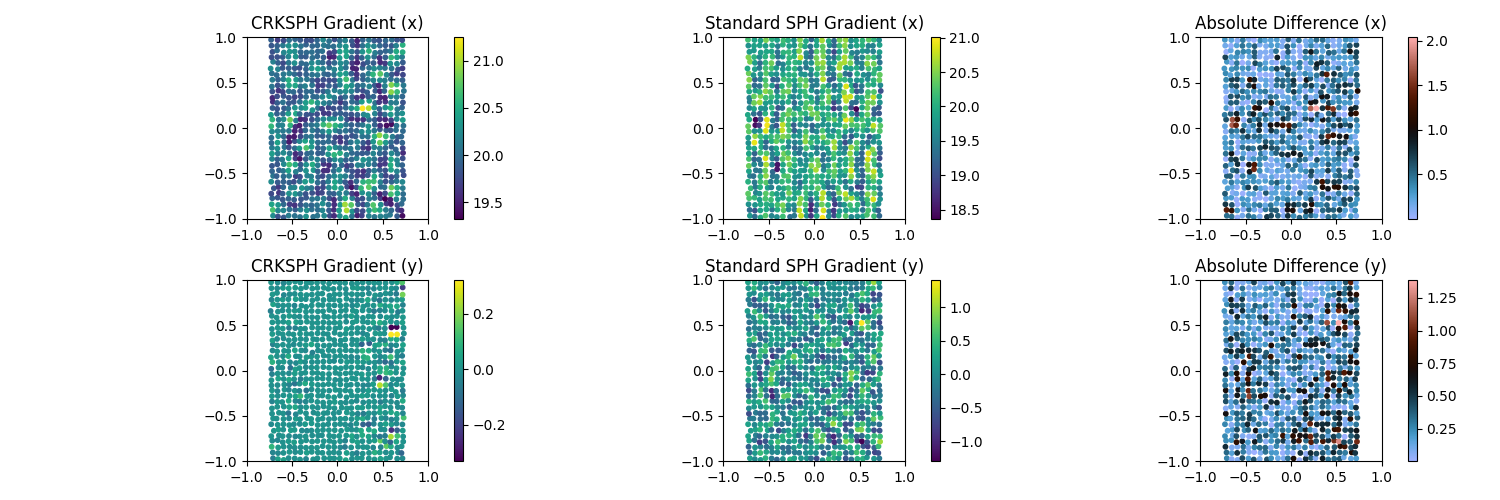

In [99]:
f_grad_crk = SPHOperation(
    simulationState,
    quantity = f,
    kernel = KernelType.Wendland2,
    neighborhood = neighborhood[0],
    kernelValues = neighborhood[1],
    operation= Operation.Gradient,
    supportScheme = DiffSPHSupportScheme.Gather,
    gradientMode = GradientMode.Difference,
    correctionTerms= [KernelCorrectionScheme.CRKSPH],
    positiveDivergence=False,
    useApparentArea=True
)
f_grad = SPHOperation(
    simulationState,
    quantity = f,
    kernel = KernelType.Wendland2,
    neighborhood = neighborhood[0],
    kernelValues = neighborhood[1],
    operation= Operation.Gradient,
    supportScheme = DiffSPHSupportScheme.Gather,
    gradientMode = GradientMode.Difference,
    correctionTerms= [],
    positiveDivergence=False
)


mask = torch.logical_and(referencePositions[:,0] > -0.75, referencePositions[:,0] < 0.75)
fig, axis = plt.subplots(2,3, figsize = (15,5), squeeze=False)

c = axis[0,0].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = result[mask,0].cpu(), s = 10)
axis[0,0].set_title("CRKSPH Gradient (x)")
fig.colorbar(c, ax = axis[0,0])

c = axis[0,1].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = f_grad[mask,0].cpu(), s = 10)
axis[0,1].set_title("Standard SPH Gradient (x)")
fig.colorbar(c, ax = axis[0,1])

diff = torch.abs(result[mask,0] - f_grad[mask,0])
c = axis[0,2].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = diff.cpu(), s = 10, cmap = 'berlin')
axis[0,2].set_title("Absolute Difference (x)")
fig.colorbar(c, ax = axis[0,2])

c = axis[1,0].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = result[mask,1].cpu(), s = 10)
axis[1,0].set_title("CRKSPH Gradient (y)")
fig.colorbar(c, ax = axis[1,0])

c = axis[1,1].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = f_grad[mask,1].cpu(), s = 10)
axis[1,1].set_title("Standard SPH Gradient (y)")
fig.colorbar(c, ax = axis[1,1])

diff = torch.abs(result[mask,1] - f_grad[mask,1])
c = axis[1,2].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = diff.cpu(), s = 10, cmap = 'berlin')    
axis[1,2].set_title("Absolute Difference (y)")
fig.colorbar(c, ax = axis[1,2])

for a in axis.flatten():
    a.set_aspect('equal')
    a.set_xlim(domain.min[0].item(), domain.max[0].item())
    a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [ ]:
f = torch.randn_like(referenceDensities)

fig, axis = plt.subplots(1,1, figsize = (7,5), squeeze=False)

axis[0,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f.cpu(), s = 10, cmap = 'berlin')
axis[0,0].set_title("Random Field f")
fig.colorbar(c, ax = axis[0,0])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()


In [ ]:
f_interpolated_warp = sphOperation_warp(
        queryPositions, referencePositions, 
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f, f,
        domain, adjacency,
        operation=WarpOperation.Interpolate,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather
)

f_interpolated_diffSPH = SPHOperation(
        simulationState,
        quantity = f,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Interpolate,
        supportScheme = SupportScheme.Gather,
        correctionTerms= [],
)

fig, axis = plt.subplots(1,3, figsize = (15,5), squeeze=False)

c = axis[0,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_interpolated_warp.cpu(), s = 10)
axis[0,0].set_title("WarpSPH Interpolation")
fig.colorbar(c, ax = axis[0,0])

c = axis[0,1].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_interpolated_diffSPH.cpu(), s = 10)
axis[0,1].set_title("diffSPH Interpolation")
fig.colorbar(c, ax = axis[0,1])

diff = torch.abs(f_interpolated_warp - f_interpolated_diffSPH)
c = axis[0,2].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = diff.cpu(), s = 10, cmap = 'berlin')
axis[0,2].set_title("Absolute Difference")
fig.colorbar(c, ax = axis[0,2])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [ ]:
f_gradient_warp = sphOperation_warp(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_interpolated_warp, f_interpolated_warp,
        domain, adjacency,
        operation=WarpOperation.Gradient,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather,
        gradientMode = GradientScheme.Difference
)
f_gradient_warp = sphOperation_warp(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        None, None,
        domain, adjacency,
        operation=WarpOperation.Gradient,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather,
        gradientMode = GradientScheme.Naive,
        preScatteredQuantities=f_interpolated_warp[adjacency.j] - f_interpolated_warp[adjacency.i]
)

f_gradient_diffSPH = SPHOperation(
        simulationState,
        quantity = f_interpolated_warp,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
)

fig, axis = plt.subplots(2,3, figsize = (12,7), squeeze=False, sharex=True, sharey=True)

for d in range(2):
    c = axis[d,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_gradient_warp[:,d].cpu(), s = 10)
    axis[d,0].set_title(f"WarpSPH Gradient - Dim {d}")
    fig.colorbar(c, ax = axis[d,0])

    c = axis[d,1].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_gradient_diffSPH[:,d].cpu(), s = 10)
    axis[d,1].set_title(f"diffSPH Gradient - Dim {d}")
    fig.colorbar(c, ax = axis[d,1])

    diff = torch.abs(f_gradient_warp - f_gradient_diffSPH)
    c = axis[d,2].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = diff[:,d].cpu(), s = 10, cmap = 'berlin')
    axis[d,2].set_title(f"Absolute Difference - Dim {d}")
    fig.colorbar(c, ax = axis[d,2])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [ ]:
from sphWarpCore.operations.wp_covariance import computeSPHCovariance_warpBackend
from diffSPH.math import pinv2x2

C = computeSPHCovariance_warpBackend(
    queryPositions, referencePositions, 
    querySupports, referenceSupports, 
    queryMasses, referenceMasses, 
    queryDensities, referenceDensities, 
    domain = domain, adjacency = adjacency, 
    mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, renormalizationMatrices = None)

num_nbrs = adjacency.numNeighbors
dtype = C.dtype

C[num_nbrs < 4,:,:] = torch.eye(dim, dtype = dtype, device = device)[None,:,:]

if queryPositions.shape[1] == 2:
    L, eigVals = pinv2x2(C)
else:
    L = torch.linalg.pinv(C)
    eigVals = torch.linalg.eigvals(C).real

    if queryPositions.shape[1] == 3:
        eigVals[torch.abs(eigVals[:,1]) > torch.abs(eigVals[:,0]),:] = torch.flip(eigVals[torch.abs(eigVals[:,1]) > torch.abs(eigVals[:,0]),:],[1])
        eigVals[torch.abs(eigVals[:,2]) > torch.abs(eigVals[:,1]),:] = torch.flip(eigVals[torch.abs(eigVals[:,2]) > torch.abs(eigVals[:,1]),:],[1])
        eigVals[torch.abs(eigVals[:,2]) > torch.abs(eigVals[:,0]),:] = torch.flip(eigVals[torch.abs(eigVals[:,2]) > torch.abs(eigVals[:,0]),:],[1])


In [ ]:
C

In [ ]:
from diffSPH.modules.renorm import computeCovarianceMatrices

simulationState.numNeighbors = adjacency.numNeighbors

C_diffSPH, L, eigVals = computeCovarianceMatrices(
    simulationState,
    neighborhood = neighborhood,
    kernel = KernelType.Wendland2,
    supportScheme = SupportScheme.Gather
)
C_diffSPH

In [ ]:
(C_diffSPH - C).max()

In [ ]:

f_gradient_warp = sphOperation_warp(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_interpolated_warp, f_interpolated_warp,
        domain, adjacency,
        operation=WarpOperation.Gradient,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather,
        gradientMode = GradientScheme.Difference,
        renormalizationMatrices=L
)

from diffSPH.operations import KernelCorrectionScheme

simulationState.gradCorrectionMatrices = L
f_gradient_diffSPH = SPHOperation(
        simulationState,
        quantity = f_interpolated_warp,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= [KernelCorrectionScheme.gradientRenorm]
)

fig, axis = plt.subplots(2,3, figsize = (12,7), squeeze=False, sharex=True, sharey=True)

for d in range(2):
    c = axis[d,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_gradient_warp[:,d].cpu(), s = 10)
    axis[d,0].set_title(f"WarpSPH Gradient - Dim {d}")
    fig.colorbar(c, ax = axis[d,0])

    c = axis[d,1].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_gradient_diffSPH[:,d].cpu(), s = 10)
    axis[d,1].set_title(f"diffSPH Gradient - Dim {d}")
    fig.colorbar(c, ax = axis[d,1])

    diff = torch.abs(f_gradient_warp - f_gradient_diffSPH)
    c = axis[d,2].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = diff[:,d].cpu(), s = 10, cmap = 'berlin')
    axis[d,2].set_title(f"Absolute Difference - Dim {d}")
    fig.colorbar(c, ax = axis[d,2])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [ ]:

from diffSPH.modules.adaptiveSmoothing import *

omega = computeOmega(simulationState, KernelType.Wendland2, neighborhood, SupportScheme.Gather, {})

print(omega)
simulationState.omega = omega

In [ ]:
f_gradient_warp = sphOperation_warp(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_interpolated_warp, f_interpolated_warp,
        domain, adjacency,
        operation=WarpOperation.Gradient,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather,
        gradientMode = GradientScheme.Difference,
        # renormalizationMatrices=L,
        queryOmegas=omega, referenceOmegas=omega,
)

from diffSPH.operations import KernelCorrectionScheme

simulationState.gradCorrectionMatrices = L
f_gradient_diffSPH = SPHOperation(
        simulationState,
        quantity = f_interpolated_warp,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= [KernelCorrectionScheme.gradH]
)

fig, axis = plt.subplots(2,3, figsize = (12,7), squeeze=False, sharex=True, sharey=True)

for d in range(2):
    c = axis[d,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_gradient_warp[:,d].cpu(), s = 10)
    axis[d,0].set_title(f"WarpSPH Gradient - Dim {d}")
    fig.colorbar(c, ax = axis[d,0])

    c = axis[d,1].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_gradient_diffSPH[:,d].cpu(), s = 10)
    axis[d,1].set_title(f"diffSPH Gradient - Dim {d}")
    fig.colorbar(c, ax = axis[d,1])

    diff = torch.abs(f_gradient_warp - f_gradient_diffSPH)
    c = axis[d,2].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = diff[:,d].cpu(), s = 10, cmap = 'berlin')
    axis[d,2].set_title(f"Absolute Difference - Dim {d}")
    fig.colorbar(c, ax = axis[d,2])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [ ]:

f_vec = torch.zeros_like(referencePositions)

u_mag = 1

k_ = 2

ktgv = k_ / 2
if k_ % 2 == 0:
    phaseShift_x = np.pi / 2# / k
    phaseShift_y = np.pi / 2# / k
else:
    phaseShift_x = 0
    phaseShift_y = 0

f_vec[:,0] =  u_mag * torch.cos(ktgv * np.pi * referencePositions[:,0] + phaseShift_x) * torch.sin(ktgv * np.pi * referencePositions[:,1] + phaseShift_y)
f_vec[:,1] = -u_mag * torch.sin(ktgv * np.pi * referencePositions[:,0] + phaseShift_x) * torch.cos(ktgv * np.pi * referencePositions[:,1] + phaseShift_y)

fig, axis = plt.subplots(1,2, figsize = (10,4), squeeze=False)

c = axis[0,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_vec[:,0].cpu(), s = 10, cmap = 'berlin')
axis[0,0].set_title("Vector Field f - Dim 0")
fig.colorbar(c, ax = axis[0,0])

c = axis[0,1].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_vec[:,1].cpu(), s = 10, cmap = 'berlin')
axis[0,1].set_title("Vector Field f - Dim 1")
fig.colorbar(c, ax = axis[0,1])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [ ]:
f_divergence_warp = sphOperation_warp(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_vec, f_vec,
        domain, adjacency,
        operation=WarpOperation.Divergence,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather,
        gradientMode = GradientScheme.Difference
)

f_gradient_diffSPH = SPHOperation(
        simulationState,
        quantity = f_vec,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Divergence,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
)

fig, axis = plt.subplots(1,3, figsize = (15,5), squeeze=False)

c = axis[0,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_divergence_warp.cpu(), s = 10)
axis[0,0].set_title("WarpSPH Divergence")
fig.colorbar(c, ax = axis[0,0])

c = axis[0,1].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_gradient_diffSPH.cpu(), s = 10)
axis[0,1].set_title("diffSPH Divergence")
fig.colorbar(c, ax = axis[0,1])

diff = torch.abs(f_divergence_warp - f_gradient_diffSPH)
c = axis[0,2].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = diff.cpu(), s = 10, cmap = 'berlin')
axis[0,2].set_title("Absolute Difference")
fig.colorbar(c, ax = axis[0,2])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [ ]:
f_curl_warp = sphOperation_warp(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_vec, f_vec,
        domain, adjacency,
        operation=WarpOperation.Curl,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather,
        gradientMode = GradientScheme.Difference
)

f_curl_diffSPH = SPHOperation(
        simulationState,
        quantity = f_vec,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Curl,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
)

fig, axis = plt.subplots(1,3, figsize = (12,4), squeeze=False, sharex=True, sharey=True)

for d in range(1):
    c = axis[d,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_curl_warp[:,d].cpu(), s = 10)
    axis[d,0].set_title(f"WarpSPH Curl - Dim {d}")
    fig.colorbar(c, ax = axis[d,0])

    c = axis[d,1].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_curl_diffSPH[:,d].cpu(), s = 10)
    axis[d,1].set_title(f"diffSPH Curl - Dim {d}")
    fig.colorbar(c, ax = axis[d,1])

    diff = torch.abs(f_curl_warp - f_curl_diffSPH)
    c = axis[d,2].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = diff[:,d].cpu(), s = 10, cmap = 'berlin')
    axis[d,2].set_title(f"Absolute Difference - Dim {d}")
    fig.colorbar(c, ax = axis[d,2])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [ ]:
f_scalar_laplacian_warp = sphOperation_warp(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_interpolated_warp, f_interpolated_warp,
        domain, adjacency,
        operation=WarpOperation.Laplacian,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather,
        gradientMode= GradientScheme.Difference,
        laplacianMode = LaplacianMode.Brookshaw
)

f_scalar_laplacian_diffSPH = SPHOperation(
        simulationState,
        quantity = f_interpolated_warp,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1], 
        operation=Operation.Laplacian,
        supportScheme = SupportScheme.Gather,
        gradientMode= GradientMode.Difference,
        laplacianMode = LaplacianMode.Brookshaw
)

fig, axis = plt.subplots(1,3, figsize = (15,5), squeeze=False)

c = axis[0,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_scalar_laplacian_warp.cpu(), s = 10)
axis[0,0].set_title("WarpSPH Laplacian")
fig.colorbar(c, ax = axis[0,0])

c = axis[0,1].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_scalar_laplacian_diffSPH.cpu(), s = 10)
axis[0,1].set_title("diffSPH Laplacian")
fig.colorbar(c, ax = axis[0,1])

diff = torch.abs(f_scalar_laplacian_warp - f_scalar_laplacian_diffSPH)
c = axis[0,2].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = diff.cpu(), s = 10, cmap = 'berlin')
axis[0,2].set_title("Absolute Difference")
fig.colorbar(c, ax = axis[0,2])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()
